# Part 4 — Vector Databases

4.1 — Embedding & Similarity

In [8]:
!pip install sentence-transformers

In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
sentences = [
    # Cricket (3)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker to take a wicket",
    "The team won the cricket match by chasing a huge target",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Cooking requires the right balance of spices and flavors",
    "She baked a chocolate cake in the oven for dessert",

    # Cybersecurity (4)
    "Cybersecurity protects systems from digital attacks and hackers",
    "Strong passwords help in securing online accounts from breaches",
    "Firewalls are used to prevent unauthorized access to networks",
    "Encryption ensures that sensitive data remains protected"
]

In [11]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Shape of embeddings:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of embeddings: (10, 384)


In [12]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 0.9999999   0.48026192  0.5988264  -0.02352582  0.03556508  0.02856926
   0.02121019  0.00659086  0.03130472  0.00727374]
 [ 0.48026192  0.99999994  0.47880667  0.15128493  0.12808304  0.10645561
  -0.01889895  0.04375674  0.0042023  -0.01525957]
 [ 0.5988264   0.47880667  1.0000002  -0.0664753  -0.00916818  0.05722876
   0.02954293 -0.0061125   0.07585476  0.03158347]
 [-0.02352582  0.15128493 -0.0664753   1.0000001   0.3437943   0.2569906
  -0.0012675   0.0126606   0.04365366  0.03054479]
 [ 0.03556508  0.12808304 -0.00916818  0.3437943   1.          0.13711473
  -0.00394531  0.10246088  0.05810986 -0.02207242]
 [ 0.02856926  0.10645561  0.05722876  0.2569906   0.13711473  1.
   0.02336453 -0.07791249  0.0222277   0.07472198]
 [ 0.02121019 -0.01889895  0.02954293 -0.0012675  -0.00394531  0.02336453
   1.0000001   0.44650686  0.44947082  0.37633598]
 [ 0.00659086  0.04375674 -0.0061125   0.0126606   0.10246088 -0.07791249
   0.44650686  1.0000002   0.33073103  0.27279425]
 [ 0.0313

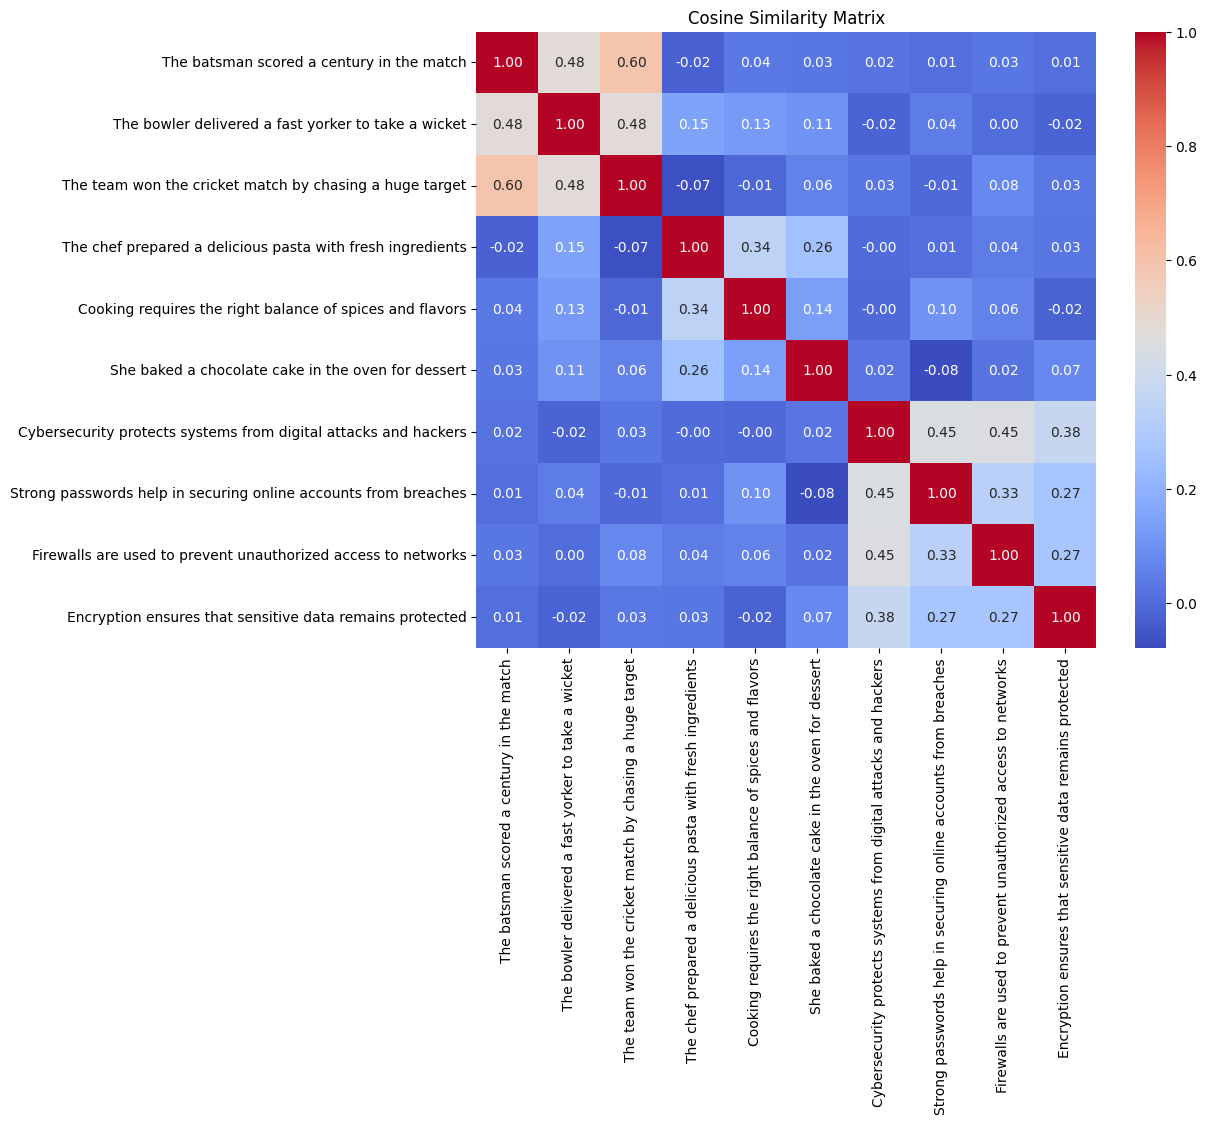

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(similarity_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            xticklabels=sentences,
            yticklabels=sentences)

plt.title("Cosine Similarity Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [14]:
query = "The bowler took three wickets in one over"

# Convert query to embedding
query_embedding = model.encode([query])

# Compare with all sentences
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(sentences[idx])
    print("Similarity Score:", similarities[idx])
    print()

Query: The bowler took three wickets in one over

Top 2 similar sentences:

The bowler delivered a fast yorker to take a wicket
Similarity Score: 0.6654506

The batsman scored a century in the match
Similarity Score: 0.56821966

